# Analiza podatkov o prometnih nesrečah v Sloveniji

1. Datoteke moramo najprej združiti v en dataframe objekt in nato počistiti napačne in manjkajoče vrednosti

In [1]:
import pandas as pd
import glob
import os
import numpy as np

path = "PN_datasets"
files = glob.glob(os.path.join(path, "*.csv")) #Get all .csv files from the PN_datasets folder

df_list = []

# For every file(year) add a column in each file that will be the unique accident ID across all files format:
# <year>_<accident_id> 
                  
for file in files:
    temp_df = pd.read_csv(file, sep=';', encoding="windows-1250") # ALL FILES USE THE WINDOWS-1250 ENCODING
    year = "".join(filter(str.isdigit, os.path.basename(file)))
    temp_df['ID'] = year + "_" + temp_df['ZaporednaStevilkaPN'].astype(str)
    
    df_list.append(temp_df)    
                  
master_df = pd.concat(df_list, ignore_index=True) #merge all files into one dataframe          

#print(master_df.isnull().sum()) # Check the sum of missing value across all atributes


2. Znebiti se moramo manjkajočih vrednosti. Največkrat tako, da dodamo nov razred "NEZNANO" ali podobno. Pri starosti lahko tudi vnesemo mediano vseh starosti ampak to je lahko za nadalnjo analizo moteče

In [2]:
# Cleaning / inserting missing values

# Looking at the data it would seem that people without a UE entry were mostly foreigners by nationality.
# Add a new classification for "TUJINA" in such cases
master_df["UEStalnegaPrebivalisca"] = master_df["UEStalnegaPrebivalisca"].fillna("TUJINA")  
master_df["UEStalnegaPrebivalisca"] = master_df["UEStalnegaPrebivalisca"].replace("NEZNANA OBČ", "TUJINA")

# There is a few missing entries for UEStoritve. Added new class "NEZNANO" since it's not that crucial for our analysis
master_df["UpravnaEnotaStoritve"] = master_df["UpravnaEnotaStoritve"].fillna("NEZNANO")


In [3]:
# When looking at the sum of missing values by attribute it would seem that attributes 
# "Povzrocitelj", "PoskodbaUdelezenca", "VrstaUdelezenca", "Starost" and "UporabaVarnostnegaPasu" are all missing 
# 4300 times so there is obviously something wrong with these entries since no data about the person was gathered
# here we deleted all such entires
master_df.dropna(subset=["Povzrocitelj", "PoskodbaUdelezenca", "VrstaUdelezenca", "UporabaVarnostnegaPasu"], inplace=True)
    
#There was a lot of ages marked as -1 so I decided to input the median age instead (in case we use random algorithms
#that dont do well with missing values)
master_df["Starost"] = master_df["Starost"].replace("NEZNANA OBČ", np.nan) # set missing values to nan before calculating median


#####
# SET MISSING AGE TO MEDIAN??? BEWARE WHEN DOING ANALYSIS
#####

#master_df["Starost"] = master_df["Starost"].fillna(master_df["Starost"].median())


In [4]:
# For people entries wihout a nationality default to "Slovenija" if they aren't labled at "TUJINA" in "UEStalnegaPrebivalisca"
condition = (master_df["Drzavljanstvo"].isna()) & (master_df["UEStalnegaPrebivalisca"] != "TUJINA")
master_df.loc[condition, "Drzavljanstvo"] = "Slovenija"

master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].fillna("NEZNANO")

# Clean inconsistent missing nationality lables
master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].replace(["OSEBA IMA NEZNANO DRŽAVLJANSTVO", "BREZ DRŽAVLJANSTVA"], "NEZNANO")

# Lowercase Slovenija -> SLOVENIJA
master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].replace("Slovenija", "SLOVENIJA")

In [5]:
# Merge "TEKOČ (NORMALEN)" with "NORMALEN" for attribute "StanjePrometa"
master_df["StanjePrometa"] = master_df["StanjePrometa"].replace("NORMALEN", "TEKOČ (NORMALEN)")


# Cap driving licence years to 85 (max was around 90 which is probably wrong??)
master_df['VozniskiStazVLetih'] = master_df['VozniskiStazVLetih'].clip(upper=85)

# The value 0 in VozniskiStazVLetih could be interpreted as an underage person, a passenger, person driving without
# a valid licence, person walking ... It's not clear what the 0 is so I will not input or change it.
# The same goes for "VozniskiStazVMesecih"


# Cap sobriety test results at around 3.00 mg/l (considered to be a deadly dose)
# NOTE: Test result might be 0 even if it wasn't done
# First convert result strings to float
master_df['VrednostAlkotesta'] = master_df['VrednostAlkotesta'].astype(str).str.replace(',', '.')
master_df['VrednostAlkotesta'] = pd.to_numeric(master_df['VrednostAlkotesta'], errors='coerce')
master_df['VrednostAlkotesta'] = master_df['VrednostAlkotesta'].clip(upper=3.50)

#Medical sobriety test results look very wrong and inconsistent. I don't expect to use them in this analysis so
#I will simply delete the column
master_df = master_df.drop(columns=['VrednostStrokovnegaPregleda'])


In [6]:
#with pd.option_context('display.max_rows', None):
#    print(master_df["VrednostStrokovnegaPregleda"].value_counts(dropna=False))


In [7]:
master_df.to_csv("merged_clean.csv")

# Analiza
### 1. Kateri dnevi v letu so najnevarnejši?
Podatke združimo samo po dnevih, brez leta, in jih prestejemo.

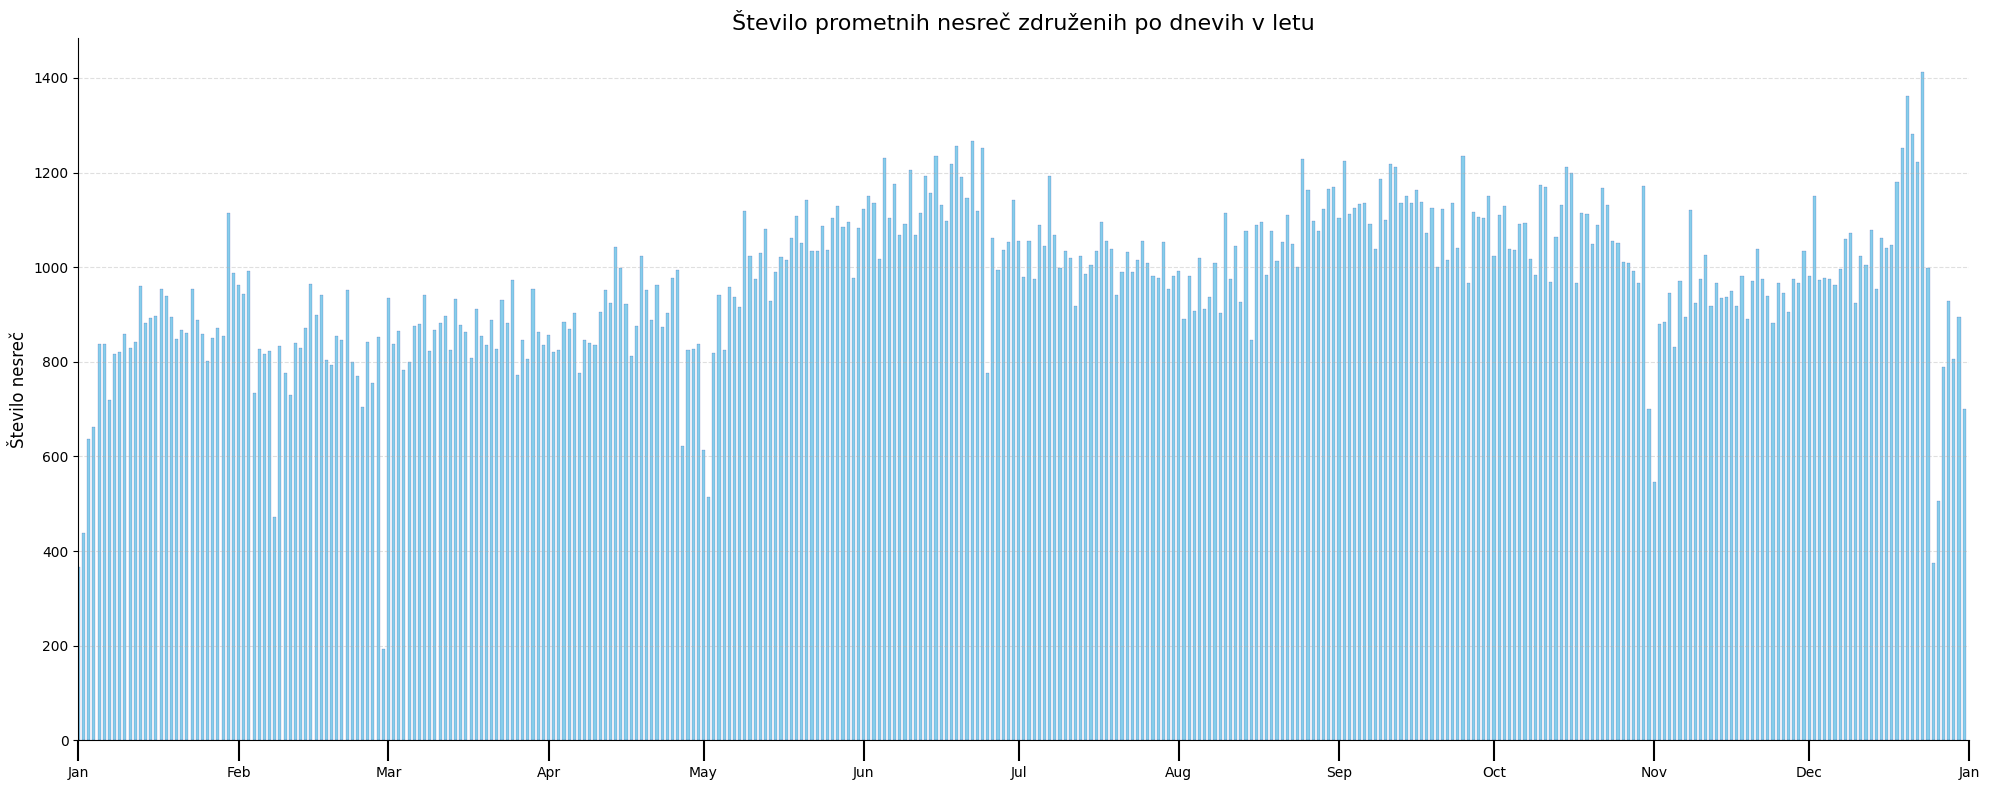

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

master_df = pd.read_csv("merged_clean.csv")

master_df['DatumPN'] = pd.to_datetime(master_df['DatumPN'], dayfirst=True)
daily_counts = master_df.groupby([
    master_df['DatumPN'].dt.month, 
    master_df['DatumPN'].dt.day
]).size()

#Use 2024 to draw x axis ticks since it was a leap year
plot_dates = [pd.Timestamp(year=2024, month=m, day=d) for m, d in daily_counts.index]
counts = daily_counts.values

plt.figure(figsize=(20, 8))

plt.bar(plot_dates, counts, width=0.6, color='skyblue', edgecolor='navy', linewidth=0.1) 

ax = plt.gca()
ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2025-01-01'))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax.tick_params(axis='x', which='major', length=15, width=1.5, direction='out', color='black')

plt.title('Število prometnih nesreč združenih po dnevih v letu', fontsize=16)
plt.ylabel('Število nesreč', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



Iz grafa lahko razberemo nekaj zanimivih datumov, kjer so nesreče manj verjetne. Večinoma se dnevi z manj nesrečami ujemajo z dela prostimi dnevi, kot so praznik dela, dan državnosti in božičem. Okoli božiča je še posebej izrazit "naval" pred praznikom in majhna verjetnost po prazniku, ki narašča vse do novega leta, kjer se ponovno zmanjša. Vidimo lahko tudi, da sta v povprečju najnevarnejši obdobji pred božičem in meseci v začetku poletja

Še ena posebnost, ki jo velja omeniti je 29. februar, ki se zaradi prestopnega leta v podatkih pojavi štirikrat manj kot ostali, vendar to še ne pomeni, da je ta dan bolj "varen".

### 2. Katere ure in dnevi v tednu so najnevarnejši?
Tukaj podobno. Iz datumov posamezno izluščimo datume in ure, ter jih združimo. Združene pojavitve preštejemo, da dobimo količino.

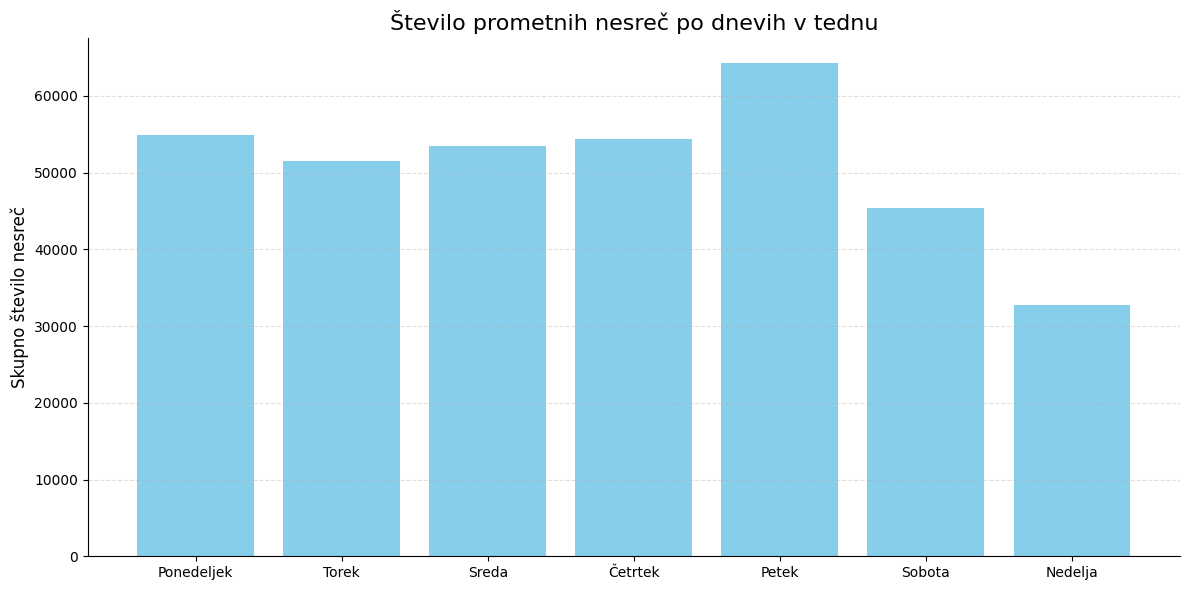

In [9]:
# Reset master_df to its original state (we are changing it in eachz exercize, so it makes sense to create a clean one)
master_df = pd.read_csv("merged_clean.csv") 


master_df['DatumPN'] = pd.to_datetime(master_df['DatumPN'], dayfirst=True)

weekday_counts = master_df.groupby(master_df['DatumPN'].dt.dayofweek).size()

days = ['Ponedeljek', 'Torek', 'Sreda', 'Četrtek', 'Petek', 'Sobota', 'Nedelja']

plt.figure(figsize=(12, 6))

plt.bar(days, weekday_counts, width=0.8, color='skyblue', edgecolor='none')

ax = plt.gca()

plt.title('Število prometnih nesreč po dnevih v tednu', fontsize=16)
plt.ylabel('Skupno število nesreč', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

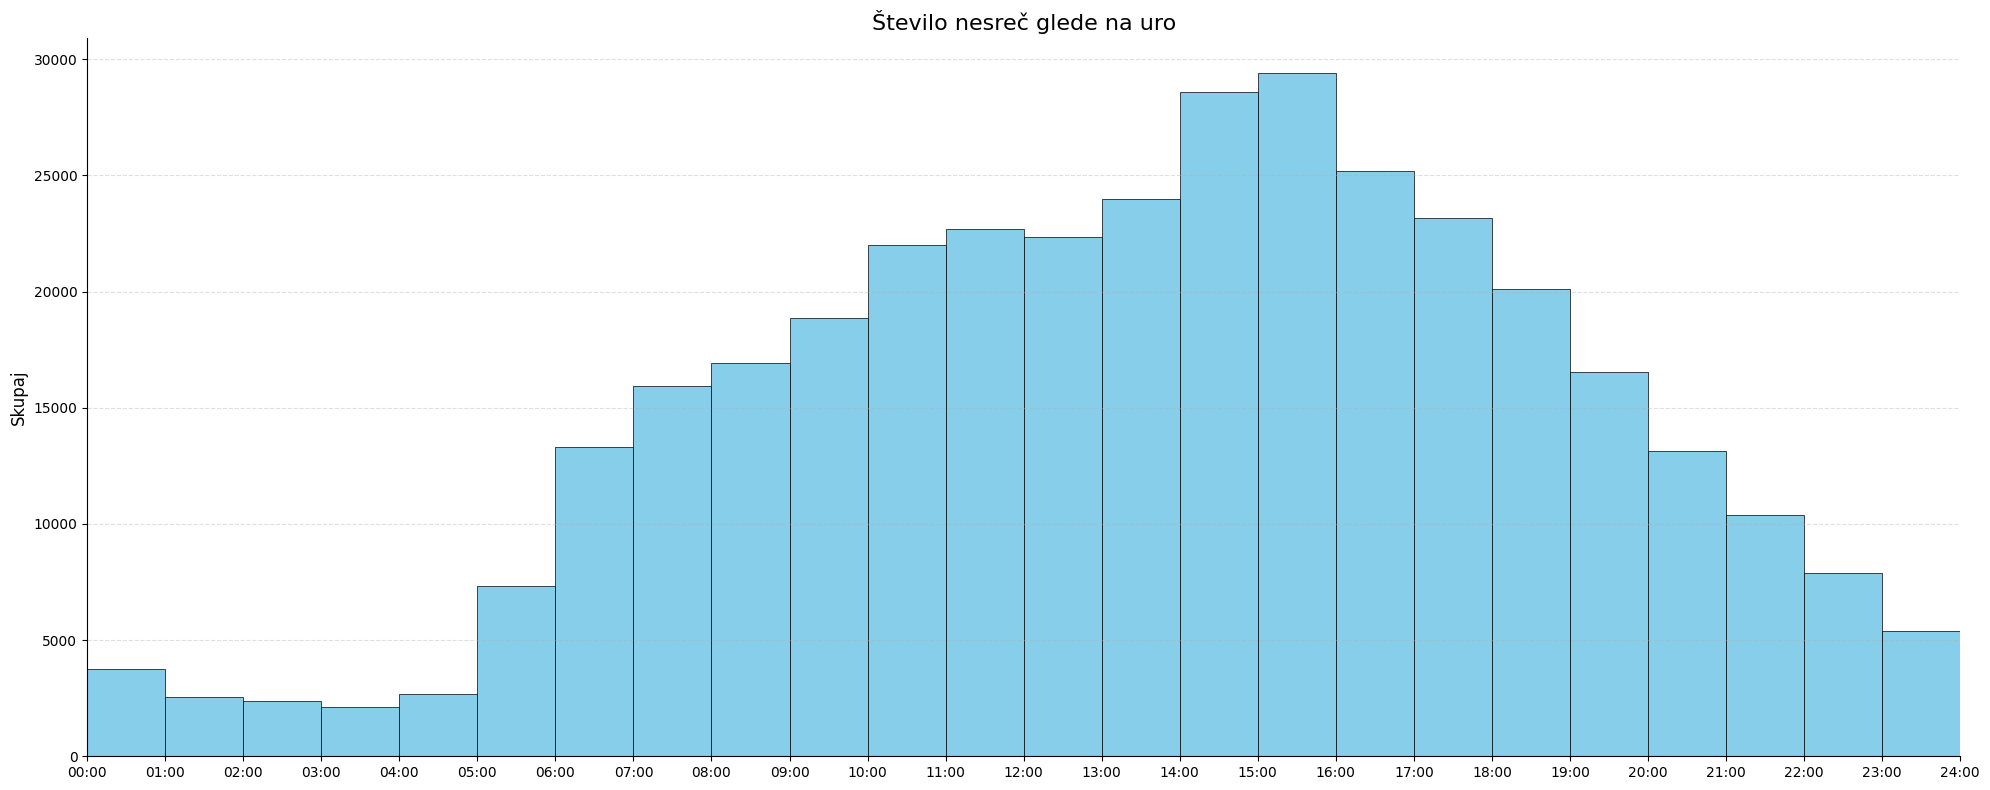

In [10]:
master_df = pd.read_csv("merged_clean.csv") 

master_df['hour'] = master_df['UraPN'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
master_df['hour'] = master_df['hour'].clip(0, 23)

hourly_counts = master_df.groupby('hour').size().reindex(range(24), fill_value=0)

plt.figure(figsize=(20, 8))

plt.bar(hourly_counts.index, hourly_counts.values, width=1.0, color='skyblue', edgecolor='black', linewidth=0.5, align='edge')

ax = plt.gca()
ax.set_xticks(range(0, 25))
ax.set_xticklabels([f"{h:02d}:00" for h in range(25)])
ax.set_xlim(0, 24)

plt.title('Število nesreč glede na uro', fontsize=16)
plt.ylabel('Skupaj', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Tudi pri teh dveh primerih so podatki povsem pričakovani

### 3. Kdaj so bolj verjetne večje nesreče (3 ali več udeleženih)?

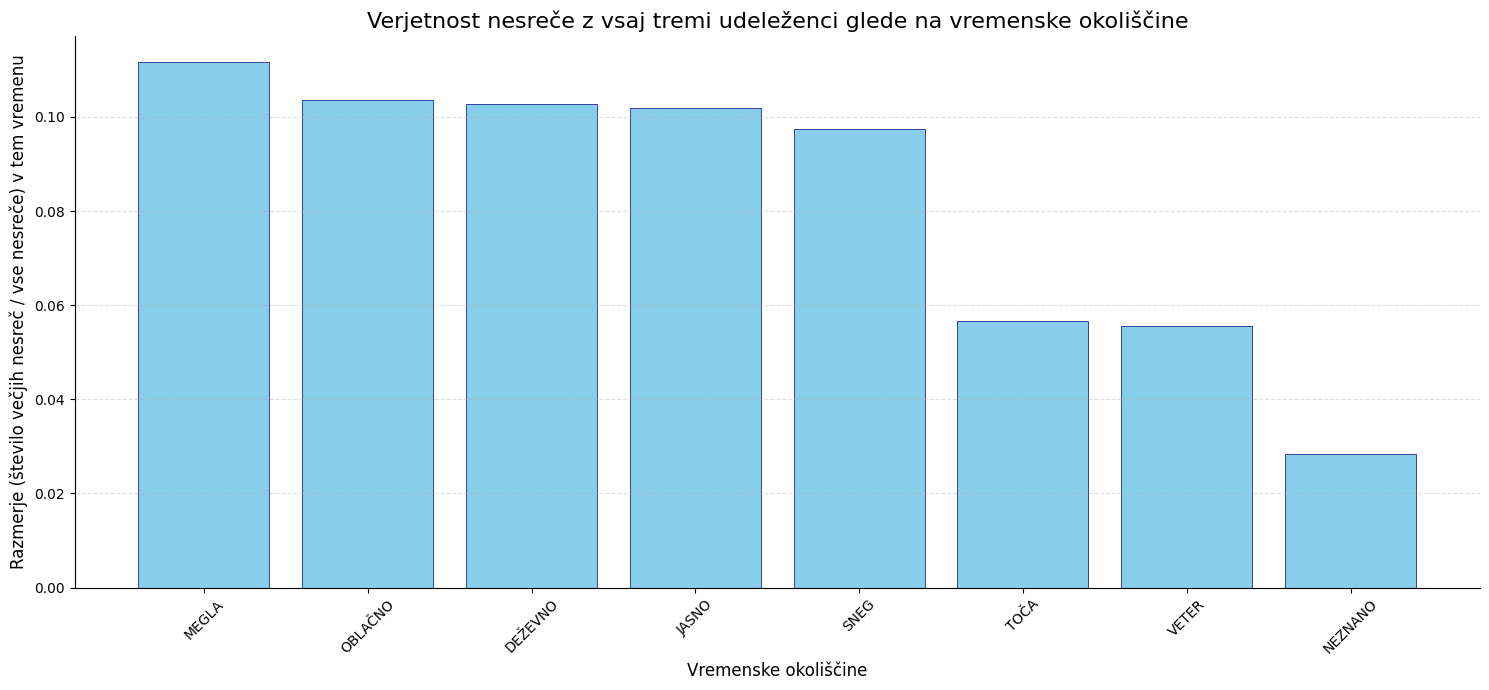

In [11]:
total_accidents_per_weather = master_df.groupby('VremenskeOkoliscine')['ID'].nunique()
total_accidents_per_weather

large_accidents_df = master_df.groupby(['ID', 'VremenskeOkoliscine']).filter(lambda x: len(x) >= 3)
large_accidents_per_weather = large_accidents_df.groupby('VremenskeOkoliscine')['ID'].nunique()

normalized_ratios = (large_accidents_per_weather / total_accidents_per_weather).fillna(0)
normalized_ratios = normalized_ratios.sort_values(ascending=False)

plt.figure(figsize=(15, 7))
plt.bar(normalized_ratios.index, normalized_ratios.values, color='skyblue', edgecolor='navy', linewidth=0.5)

ax = plt.gca()
plt.title('Verjetnost nesreče z vsaj tremi udeleženci glede na vremenske okoliščine', fontsize=16)
plt.ylabel('Razmerje (število večjih nesreč / vse nesreče) v tem vremenu', fontsize=12)
plt.xlabel('Vremenske okoliščine', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Pri tem primeru smo želeli pokazati korelacijo med večjimi nesrečami (tipično naleti) in vremenskimi okoliščinami. Hitro smo ugotovili, da se večina nesreč zgodi pri jasnem vremenu, zato smo morali podatke najprej normalizirati tako, da smo verjetnost računali kot razmerje med št. velikih nesreč deljeno z vsemi nesrečami znotraj vremenske okoliščine.
Izkaže se, da je verjetnost večje nesreče najbolj verjetna kadar je megla, nekoliko presenetljivo pa je dejstvo, da je na drugem mestu oblačno vreme, namesto naprimer deževno ali sneg.

### 3. Letni trend vožnje pod vplivom alkohola med mladimi vozniki.

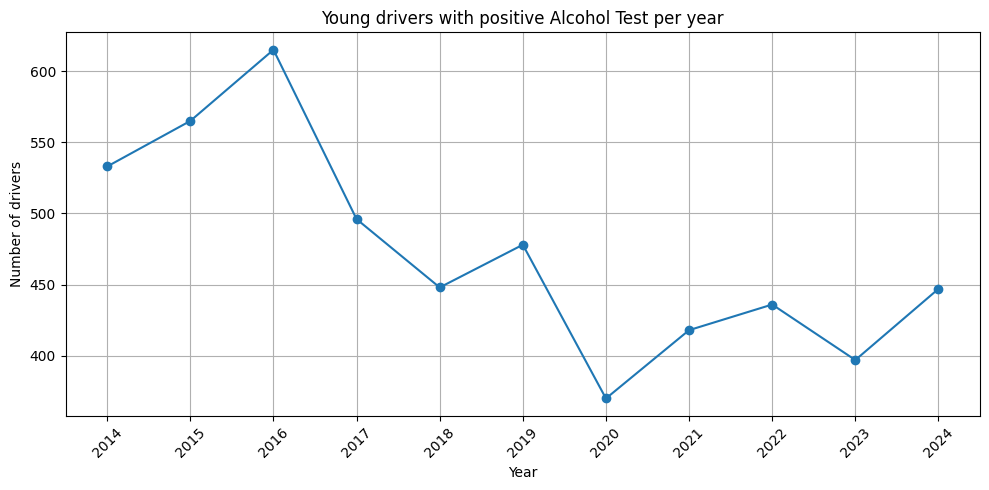

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

master_df = pd.read_csv("merged_clean.csv")
master_df['Starost'] = master_df['Starost'].replace(" ", None)
master_df['Starost'] = pd.to_numeric(master_df['Starost'], errors='coerce')
master_df['VrednostAlkotesta'] = pd.to_numeric(master_df['VrednostAlkotesta'], errors='coerce')
master_df['DatumPN'] = pd.to_datetime(master_df['DatumPN'], dayfirst=True)

young_drivers = master_df[(master_df['Starost'] > 12) & (master_df['Starost'] < 30) & (master_df['VrednostAlkotesta'] > 0)]

yearly = young_drivers.groupby(young_drivers['DatumPN'].dt.year).size()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker="o")
plt.title('Young drivers with positive Alcohol Test per year')
plt.xlabel('Year')
plt.ylabel('Number of drivers')
plt.xticks(yearly.index, rotation= 45)
plt.grid(True)
plt.tight_layout()
plt.show()

Če upoštevamo, da je bilo leto 2020 odstopajoče zaradi COVID-19, lahko rečemo, da med mladimi vozniki vožnja pod vplivom alkohola upada, pri čemer so prisotna le manjša odstopanja.